# Notebook 1 — Analyse Exploratoire des Données (EDA)
**Projet IndabaX 2026 — Cameroun** | Prédiction du Vector Risk Index (VRI) — *Anopheles gambiae*

Pipeline : Chargement → Nettoyage → Construction VRI → Exploration → Sauvegarde


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

RANDOM_STATE = 42
TEST_YEAR    = 2025
HORIZONS     = [1, 7]
print('Imports OK.')


Imports OK.


## 1. Chargement et audit initial

In [3]:
df = pd.read_excel('../data/Dataset_complet_Meteo.xlsx')
# print(f'Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
# print(f'Villes     : {df["city"].nunique()} | Régions : {df["region"].nunique()}')
# print()
# print('Types de colonnes :')
# print(df.dtypes.to_string())
df1 = pd.read_csv('../data/Dataset_complet.csv')
df1.head()
df.head()

,id,time,weather_code,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,...,precipitation_hours,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant,shortwave_radiation_sum,et0_fao_evapotranspiration,city,region,latitude,longitude
0,1,2020-01-01,3,33.2,2026-09-21 00:00:00,2026-05-26 00:00:00,34.0,2026-06-25 00:00:00,2026-01-29 00:00:00,2020-01-01 06:22:00,...,0.0,2026-05-10 00:00:00,2026-05-24 00:00:00,132,20.18,4.59,Bafia,Centre,4.75,11.23
1,2,2020-01-02,3,31.9,2026-09-21 00:00:00,2026-09-25 00:00:00,2026-01-31 00:00:00,2026-03-23 00:00:00,27.0,2020-01-02 06:23:00,...,0.0,2026-05-08 00:00:00,2026-06-25 00:00:00,77,19.39,4.64,Bafia,Centre,4.75,11.23
2,3,2020-01-03,3,32.0,2026-03-19 00:00:00,25.0,2026-07-31 00:00:00,2026-02-19 00:00:00,2026-01-25 00:00:00,2020-01-03 06:23:00,...,0.0,2026-09-08 00:00:00,2026-09-25 00:00:00,65,2026-03-20 00:00:00,4.78,Bafia,Centre,4.75,11.23
3,4,2020-01-04,3,2026-05-31 00:00:00,2026-01-19 00:00:00,2026-07-24 00:00:00,32.3,2026-07-20 00:00:00,2026-04-25 00:00:00,2020-01-04 06:24:00,...,0.0,2026-02-11 00:00:00,2026-02-20 00:00:00,106,20.48,4.59,Bafia,Centre,4.75,11.23
4,5,2020-01-05,3,31.9,2026-03-19 00:00:00,2026-08-24 00:00:00,33.1,2026-03-20 00:00:00,2026-09-25 00:00:00,2020-01-05 06:24:00,...,0.0,2026-03-11 00:00:00,2026-08-23 00:00:00,100,19.98,4.39,Bafia,Centre,4.75,11.23


## 2. Correction des types
`pd.to_numeric(errors='coerce')` convertit les valeurs corrompues en NaN sans supprimer de lignes.

In [4]:
NUMERIC_COLS = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_max', 'apparent_temperature_min', 'apparent_temperature_mean',
    'precipitation_sum', 'rain_sum', 'sunshine_duration',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'shortwave_radiation_sum', 'et0_fao_evapotranspiration',
    'latitude', 'longitude',
]
nan_avant = df[NUMERIC_COLS].isnull().sum().sum()
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
nan_apres = df[NUMERIC_COLS].isnull().sum().sum()
print(f'NaN avant conversion : {nan_avant:,}')
print(f'NaN après conversion : {nan_apres:,}')
print(f'Valeurs corrompues   : {nan_apres - nan_avant:,}')


NaN avant conversion : 0
NaN après conversion : 657,408
Valeurs corrompues   : 657,408


## 3. Tri chronologique
Tri par `['city','time']` — le tri global sur `time` seul détruisait l'ordre intra-ville (bug corrigé).

In [5]:
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.sort_values(['city', 'time']).reset_index(drop=True)
print(f'Période : {df["time"].min().date()} -> {df["time"].max().date()}')
print()
print('Observations par ville :')
print(df.groupby('city')['time'].count().describe().round(0))
df['time_diff'] = df.groupby('city')['time'].diff().dt.days
gaps = df[df['time_diff'] > 1][['city', 'time', 'time_diff']]
if gaps.empty:
    print('\nAucun trou temporel — continuité journalière confirmée.')
else:
    print(f'{len(gaps)} ruptures détectées :\n{gaps.to_string(index=False)}')


Période : 2020-01-01 -> 2025-12-20

Observations par ville :
count      40.0
mean     2181.0
std         0.0
min      2181.0
25%      2181.0
50%      2181.0
75%      2181.0
max      2181.0
Name: time, dtype: float64

Aucun trou temporel — continuité journalière confirmée.


## 4. Audit des valeurs manquantes

In [6]:
missing     = df[NUMERIC_COLS].isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
audit = pd.DataFrame({'Manquants': missing, 'Pct (%)': missing_pct})
print(audit[audit['Manquants'] > 0].to_string())


                            Manquants  Pct (%)
wind_speed_10m_max              77862     89.3
apparent_temperature_min        77672     89.0
temperature_2m_mean             75732     86.8
temperature_2m_min              75235     86.2
apparent_temperature_mean       69563     79.7
temperature_2m_max              53906     61.8
wind_gusts_10m_max              45573     52.2
rain_sum                        39471     45.2
precipitation_sum               39471     45.2
apparent_temperature_max        30896     35.4
longitude                       23991     27.5
shortwave_radiation_sum         17342     19.9
et0_fao_evapotranspiration      17119     19.6
latitude                        13086     15.0
sunshine_duration                 489      0.6


## 5. Imputation adaptée par priorité
`groupby().transform()` évite les index dupliqués produits par `.apply()` (bug corrigé).

In [7]:
def impute_time_series(df, group_cols=('city', 'region')):
    df_out = df.copy().reset_index(drop=True)
    gc = list(group_cols)
    critical  = ['temperature_2m_mean','temperature_2m_max','temperature_2m_min',
                 'precipitation_sum','rain_sum']
    important = ['apparent_temperature_mean','apparent_temperature_max',
                 'apparent_temperature_min','et0_fao_evapotranspiration',
                 'wind_speed_10m_max','wind_gusts_10m_max']
    secondary = ['sunshine_duration','shortwave_radiation_sum']
    for col in critical:
        if col in df_out.columns:
            df_out[col] = df_out.groupby(gc)[col].transform(
                lambda x: x.ffill().bfill())
    for col in important:
        if col in df_out.columns:
            df_out[col] = df_out.groupby(gc)[col].transform(
                lambda x: x.interpolate(method='linear').ffill().bfill())
    for col in secondary:
        if col in df_out.columns:
            df_out[col] = df_out.groupby(gc)[col].transform(
                lambda x: x.rolling(14, min_periods=5, center=True).mean().ffill().bfill())
    for col in ['latitude', 'longitude']:
        if col in df_out.columns:
            df_out[col] = df_out.groupby('region')[col].transform(
                lambda x: x.fillna(x.median()))
    return df_out.reset_index(drop=True)

df_clean = impute_time_series(df)
nan_res = df_clean[NUMERIC_COLS].isnull().sum()
nan_res = nan_res[nan_res > 0]
if nan_res.empty:
    print('Imputation complète — aucun NaN résiduel.')
else:
    print('NaN résiduels :'); print(nan_res)


Imputation complète — aucun NaN résiduel.


## 6. Gestion des valeurs aberrantes
Clipping P1/P99 **par ville** — un IQR global confond variabilité géographique et anomalies (bug corrigé).

In [8]:
CLIP_COLS = [
    'temperature_2m_max','temperature_2m_min','temperature_2m_mean',
    'precipitation_sum','wind_speed_10m_max','wind_gusts_10m_max',
    'et0_fao_evapotranspiration','shortwave_radiation_sum',
]
def clip_by_city(df, cols, lower=0.01, upper=0.99):
    df_out = df.copy()
    for col in cols:
        if col not in df_out.columns: continue
        p_low  = df_out.groupby('city')[col].transform(lambda x: x.quantile(lower))
        p_high = df_out.groupby('city')[col].transform(lambda x: x.quantile(upper))
        n = ((df_out[col] < p_low) | (df_out[col] > p_high)).sum()
        df_out[col] = df_out[col].clip(lower=p_low, upper=p_high)
        print(f'  {col:<38}: {n:>5} valeurs écrêtées')
    return df_out

print('Clipping P1/P99 par ville :')
df_clean = clip_by_city(df_clean, CLIP_COLS)
print(f'Doublons (city,time) : {df_clean.duplicated(subset=["city","time"]).sum()}')


Clipping P1/P99 par ville :
  temperature_2m_max                    :  1128 valeurs écrêtées
  temperature_2m_min                    :   403 valeurs écrêtées
  temperature_2m_mean                   :   520 valeurs écrêtées
  precipitation_sum                     :   750 valeurs écrêtées
  wind_speed_10m_max                    :  1609 valeurs écrêtées
  wind_gusts_10m_max                    :  1469 valeurs écrêtées
  et0_fao_evapotranspiration            :  1716 valeurs écrêtées
  shortwave_radiation_sum               :  1750 valeurs écrêtées
Doublons (city,time) : 0


## 7. Construction du VRI
**Nouvelle formule pondérée (IndabaX 2026)** :

$$VRI = \left(0.4 \cdot T_{opt} + 0.35 \cdot HR_{opt} + 0.25 \cdot P_{opt}\right) \times (1 - S)$$

- $T_{opt} = \exp\left(-\frac{(T-25)^2}{2 \times 5^2}\right)$ — gaussienne centrée sur 25°C
- $HR_{opt} = \exp\left(-\frac{(HR-70)^2}{2 \times 15^2}\right)$ — gaussienne centrée sur 70% (estimée via ET0 et précipitations)
- $P_{opt} = 1$ si précipitations > 5 mm ET heures > 4h, sinon $0.5$
- $S$ = is_dry_season ∈ {0, 1} — saison sèche binaire (nov–mars)
- **VRI strictement compris entre 0 et 1** par construction (moyenne pondérée × facteur binaire)


In [9]:
def compute_vri(df):
    out = df.copy()

    # --- T_opt : gaussienne centrée sur 25°C, σ=5 ---
    out['temp_mean'] = (out['temperature_2m_max'] + out['temperature_2m_min']) / 2
    out['T_opt'] = np.exp(-0.5 * ((out['temp_mean'] - 25) / 5) ** 2)

    # --- HR_proxy (humidité non disponible → estimation via ET0 + précipitations) ---
    et0_norm  = out.groupby('city')['et0_fao_evapotranspiration'].transform(
                    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-8))
    hr_et     = 1 - et0_norm                                   # forte ET0 → air sec
    hr_precip = np.clip(out['precipitation_hours'] / 24, 0, 1) # pluie → humidité
    app_mean  = (out['apparent_temperature_max'] + out['apparent_temperature_min']) / 2
    hr_felt   = 1 / (1 + np.exp(-0.5 * (app_mean - out['temp_mean'])))
    HR_proxy  = 0.50 * hr_et + 0.30 * hr_precip + 0.20 * hr_felt

    # --- HR_opt : gaussienne centrée sur 70%, σ=15 (appliquée sur HR_proxy*100) ---
    out['HR_proxy'] = HR_proxy
    out['HR_opt']   = np.exp(-0.5 * ((HR_proxy * 100 - 70) / 15) ** 2)

    # --- P_opt : binaire/demi selon seuils biologiques ---
    out['P_opt'] = np.where(
        (out['precipitation_sum'] > 5) & (out['precipitation_hours'] > 4),
        1.0, 0.5
    )

    # --- S : saison sèche binaire (novembre → mars) ---
    out['is_dry_season'] = out['time'].dt.month.isin([11, 12, 1, 2, 3]).astype(int)

    # --- VRI final : moyenne pondérée × (1 - S) ---
    # w1=0.4 (T), w2=0.35 (HR), w3=0.25 (P) → somme = 1 → VRI ∈ [0, 1]
    out['VRI'] = (
        0.40 * out['T_opt'] +
        0.35 * out['HR_opt'] +
        0.25 * out['P_opt']
    ) * (1 - out['is_dry_season'])

    # Colonnes intermédiaires conservées pour l'analyse
    out['S_continu'] = out['is_dry_season'].astype(float)
    return out

df_clean = compute_vri(df_clean)
print('Distribution du VRI (nouvelle formule pondérée) :')
print(df_clean['VRI'].describe().round(4))
print(f'NaN dans VRI : {df_clean["VRI"].isnull().sum()}')
print(f'VRI min={df_clean["VRI"].min():.4f}  max={df_clean["VRI"].max():.4f}  '
      f'→ strictement dans [0, 1] : {df_clean["VRI"].between(0,1).all()}')


Distribution du VRI (nouvelle formule pondérée) :
count    87240.0000
mean         0.3992
std          0.3590
min          0.0000
25%          0.0000
50%          0.5193
75%          0.7264
max          1.0000
Name: VRI, dtype: float64
NaN dans VRI : 0
VRI min=0.0000  max=1.0000  → strictement dans [0, 1] : True


## 8. Statistiques descriptives

In [10]:
desc_cols = NUMERIC_COLS + ['VRI','T_opt','HR_proxy','P_opt','S_continu']
desc_cols = [c for c in desc_cols if c in df_clean.columns]
stats = df_clean[desc_cols].describe().T[['mean','std','min','50%','max']].round(3)
stats.columns = ['Moyenne','Ecart-type','Min','Médiane','Max']
print(stats.to_string())


                              Moyenne  Ecart-type       Min    Médiane        Max
temperature_2m_max             29.701       4.047    19.000     29.200     44.200
temperature_2m_min             20.206       3.130    11.000     20.000     31.400
temperature_2m_mean            24.107       3.378    16.000     24.000     36.920
apparent_temperature_max       32.746       3.940    19.000     33.000     45.900
apparent_temperature_min       22.037       4.716     6.000     22.385     33.700
apparent_temperature_mean      26.370       4.078    14.000     26.400     38.100
precipitation_sum               4.099      11.292     0.000      0.300    137.580
rain_sum                        4.268      12.308     0.000      0.300    251.100
sunshine_duration           32416.993    5027.735  9067.729  32919.030  41525.325
wind_speed_10m_max             12.209       3.393     5.153     11.798     32.571
wind_gusts_10m_max             32.563       6.051    17.900     32.800     55.480
shortwave_radiat

## 9. Dynamique temporelle du VRI — 3 villes représentatives

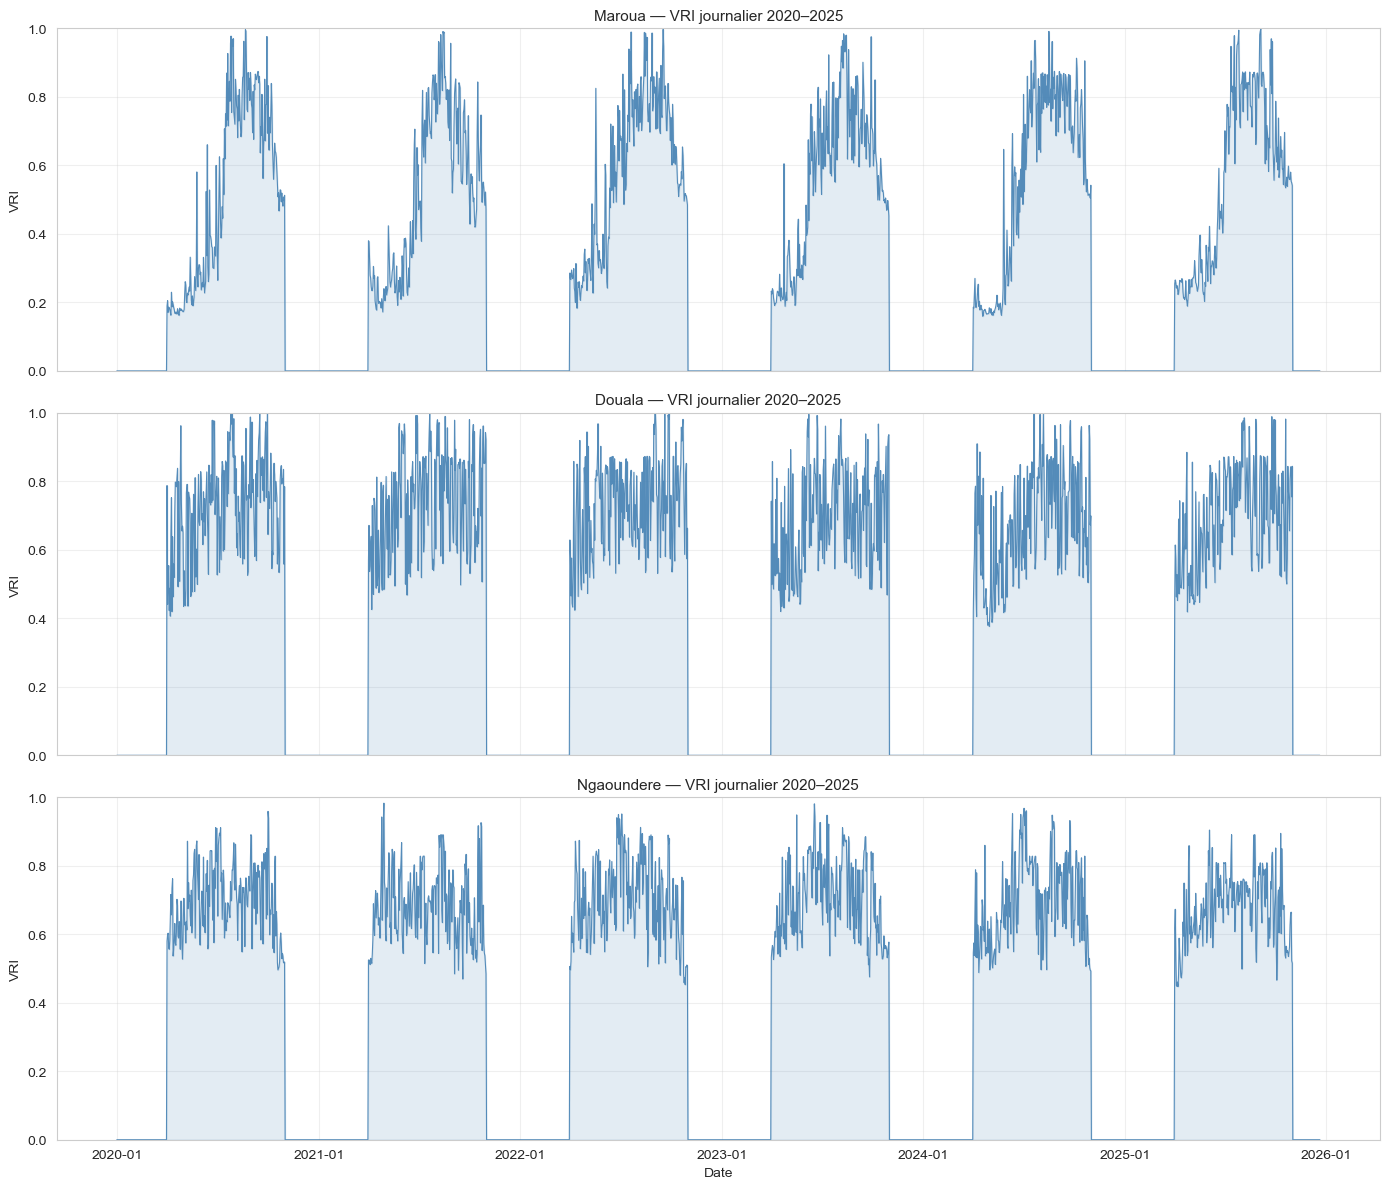

In [11]:
villes_ref = [v for v in ['Maroua','Douala','Ngaoundere'] if v in df_clean['city'].values]
if not villes_ref:
    villes_ref = df_clean['city'].unique()[:3].tolist()

fig, axes = plt.subplots(len(villes_ref), 1, figsize=(14, 4*len(villes_ref)), sharex=True)
if len(villes_ref) == 1: axes = [axes]
for ax, ville in zip(axes, villes_ref):
    s = df_clean[df_clean['city'] == ville]
    ax.plot(s['time'], s['VRI'], linewidth=0.8, color='steelblue', alpha=0.9)
    ax.fill_between(s['time'], s['VRI'], alpha=0.15, color='steelblue')
    ax.set_title(f'{ville} — VRI journalier 2020–2025', fontsize=11)
    ax.set_ylabel('VRI'); ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date')
plt.tight_layout(); plt.show()


## 10. Décomposition STL
Fs = force de saisonnalité (Wang et al. 2006). Fs > 0.64 → saisonnalité dominante.

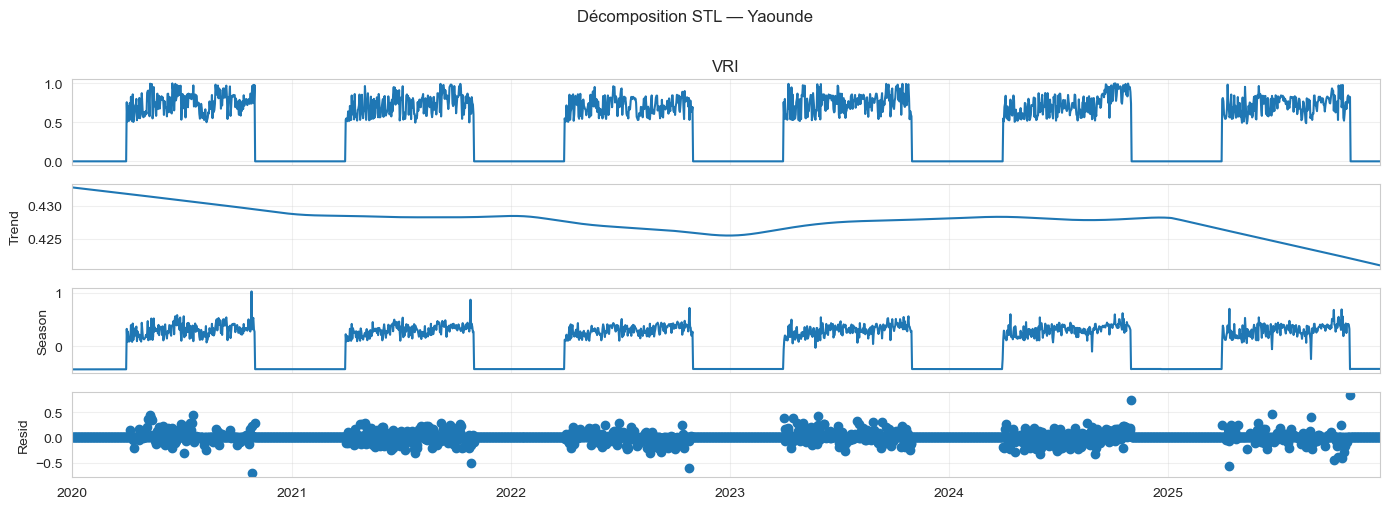

Force saisonnalité (Fs) : 0.941 -> forte
Force tendance     (Ft) : 0.003 -> moderee


In [12]:
ville_stl = 'Yaounde' if 'Yaounde' in df_clean['city'].values else df_clean['city'].iloc[0]
serie_stl = (df_clean[df_clean['city'] == ville_stl]
             .set_index('time')['VRI'].dropna().asfreq('D').interpolate())
stl = STL(serie_stl, period=365, robust=True)
res = stl.fit()
fig = res.plot()
fig.suptitle(f'Décomposition STL — {ville_stl}', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()
Fs = max(0, 1 - np.var(res.resid) / np.var(res.seasonal + res.resid))
Ft = max(0, 1 - np.var(res.resid) / np.var(res.trend   + res.resid))
print(f'Force saisonnalité (Fs) : {Fs:.3f} -> {"forte" if Fs > 0.64 else "moderee"}')
print(f'Force tendance     (Ft) : {Ft:.3f} -> {"forte" if Ft > 0.64 else "moderee"}')


## 11. ACF / PACF — lags significatifs

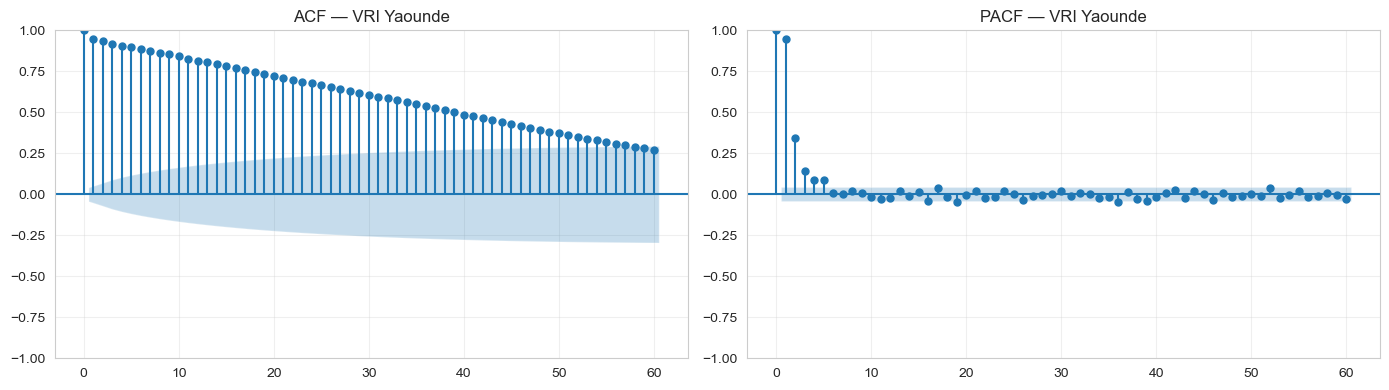

In [13]:
serie_acf = df_clean[df_clean['city'] == ville_stl]['VRI'].dropna()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( serie_acf, lags=60, ax=ax1, alpha=0.05)
plot_pacf(serie_acf, lags=60, ax=ax2, alpha=0.05, method='ywm')
ax1.set_title(f'ACF — VRI {ville_stl}'); ax2.set_title(f'PACF — VRI {ville_stl}')
plt.tight_layout(); plt.show()


## 12. Test de stationnarité ADF par ville

In [14]:
resultats_adf = []
for ville in sorted(df_clean['city'].unique()):
    s = df_clean[df_clean['city'] == ville]['VRI'].dropna()
    if len(s) < 50: continue
    stat, pval = adfuller(s, autolag='AIC')[:2]
    resultats_adf.append({'Ville': ville, 'ADF stat': round(stat,3),
                          'p-value': round(pval,4),
                          'Stationnaire': 'Oui' if pval < 0.05 else 'Non'})
df_adf = pd.DataFrame(resultats_adf)
n_stat = (df_adf['Stationnaire'] == 'Oui').sum()
print(f'Villes stationnaires     : {n_stat} / {len(df_adf)}')
print(f'Villes non-stationnaires : {len(df_adf)-n_stat} / {len(df_adf)}')
print(); print(df_adf.to_string(index=False))


Villes stationnaires     : 37 / 40
Villes non-stationnaires : 3 / 40

      Ville  ADF stat  p-value Stationnaire
Abong-Mbang    -3.388   0.0114          Oui
 Akonolinga    -3.979   0.0015          Oui
      Ambam    -3.909   0.0020          Oui
      Bafia    -3.834   0.0026          Oui
  Bafoussam    -3.706   0.0040          Oui
    Bamenda    -3.456   0.0092          Oui
    Batouri    -3.742   0.0036          Oui
    Bertoua    -3.832   0.0026          Oui
       Buea    -3.667   0.0046          Oui
     Douala    -3.680   0.0044          Oui
    Dschang    -3.773   0.0032          Oui
    Ebolowa    -4.013   0.0013          Oui
       Edea    -3.433   0.0099          Oui
    Foumban    -3.608   0.0056          Oui
     Garoua    -3.613   0.0055          Oui
     Guider    -3.080   0.0280          Oui
   Kousseri    -3.749   0.0035          Oui
      Kribi    -3.646   0.0049          Oui
      Kumba    -3.531   0.0072          Oui
      Kumbo    -3.672   0.0045          Oui
      

## 13. Matrice de corrélation

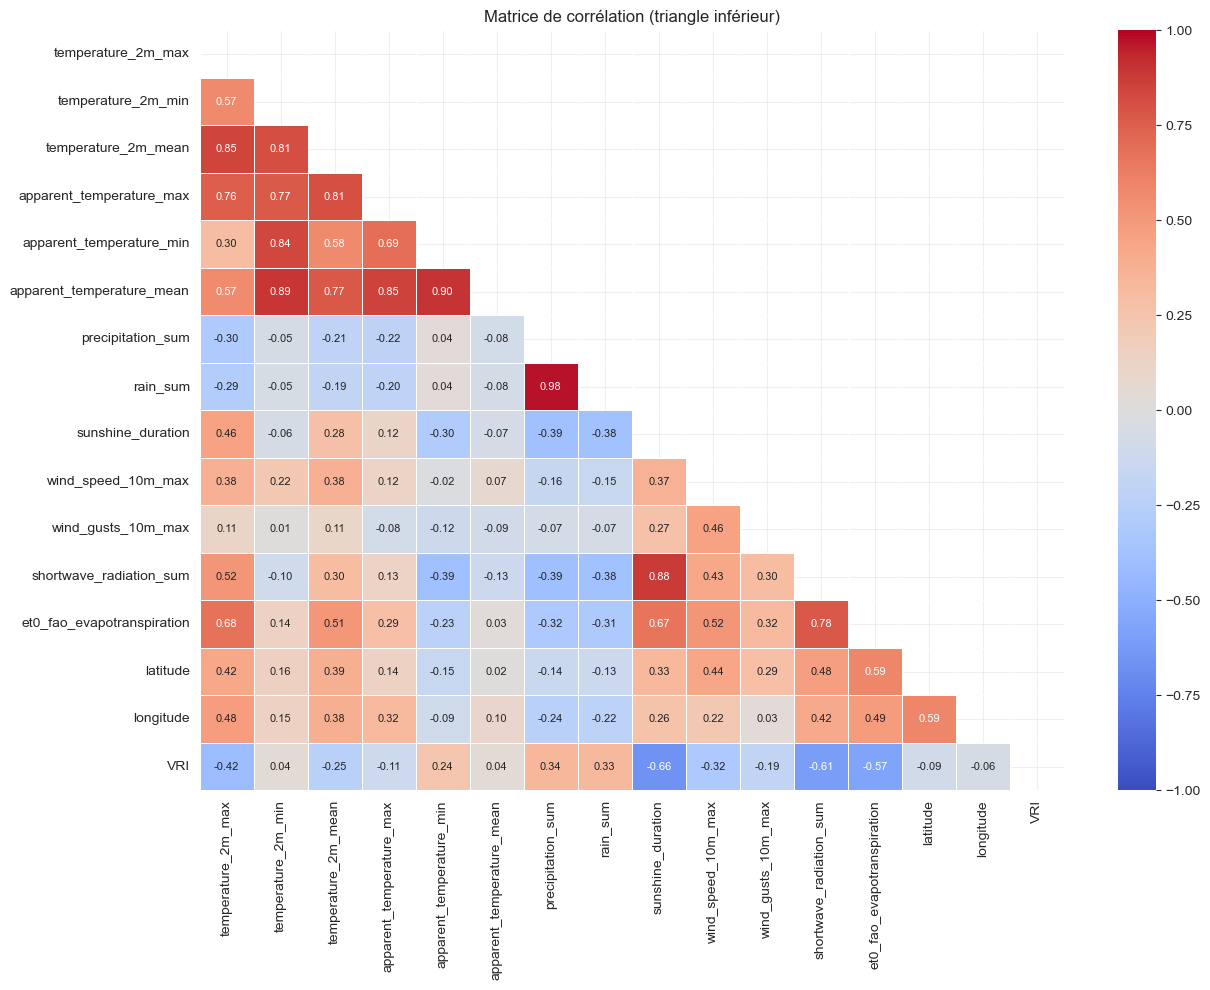

Corrélation des variables avec le VRI :
sunshine_duration            -0.659
shortwave_radiation_sum      -0.606
et0_fao_evapotranspiration   -0.568
temperature_2m_max           -0.421
precipitation_sum             0.341
rain_sum                      0.327
wind_speed_10m_max           -0.318
temperature_2m_mean          -0.249
apparent_temperature_min      0.238
wind_gusts_10m_max           -0.188
apparent_temperature_max     -0.110
latitude                     -0.093
longitude                    -0.061
apparent_temperature_mean     0.044
temperature_2m_min            0.042


In [15]:
corr_cols = [c for c in NUMERIC_COLS + ['VRI'] if c in df_clean.columns]
corr_mat  = df_clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, mask=mask, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation (triangle inférieur)')
plt.tight_layout(); plt.show()
target_corr = corr_mat['VRI'].drop('VRI').sort_values(ascending=False, key=abs)
print('Corrélation des variables avec le VRI :')
print(target_corr.round(3).to_string())


## 14. Distribution du VRI par région
Boxplot ordonné par médiane décroissante. Révèle les disparités géo et justifie la modélisation par ville.

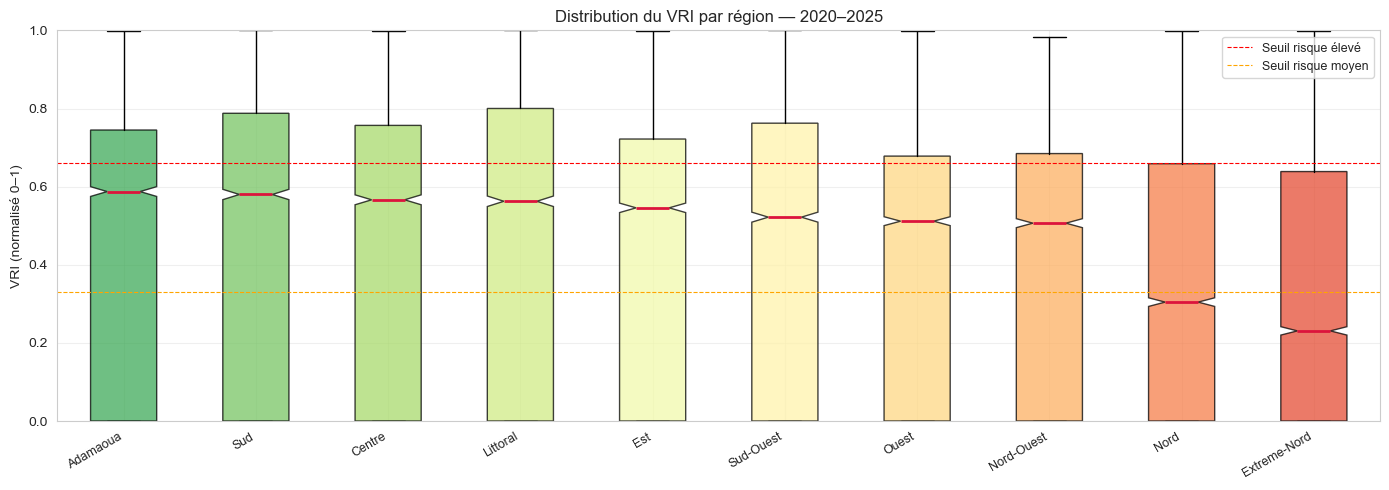

Médiane VRI par région :
              median   mean    std
region                            
Adamaoua       0.588  0.423  0.364
Sud            0.580  0.441  0.384
Centre         0.566  0.425  0.370
Littoral       0.563  0.440  0.385
Est            0.546  0.410  0.358
Sud-Ouest      0.522  0.419  0.371
Ouest          0.512  0.383  0.335
Nord-Ouest     0.507  0.384  0.338
Nord           0.304  0.344  0.332
Extreme-Nord   0.231  0.322  0.328


In [16]:
region_order = (df_clean.groupby('region')['VRI'].median()
                .sort_values(ascending=False).index.tolist())
fig, ax = plt.subplots(figsize=(14, 5))
data_by_region = [df_clean[df_clean['region'] == r]['VRI'].dropna().values
                  for r in region_order]
bp = ax.boxplot(data_by_region, patch_artist=True, notch=True,
                medianprops=dict(color='crimson', linewidth=2))
palette = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(region_order)))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(region_order, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('VRI (normalisé 0–1)')
ax.set_title('Distribution du VRI par région — 2020–2025', fontsize=12)
ax.set_ylim(0, 1)
ax.axhline(0.66, color='red',    linestyle='--', linewidth=0.8, label='Seuil risque élevé')
ax.axhline(0.33, color='orange', linestyle='--', linewidth=0.8, label='Seuil risque moyen')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print('Médiane VRI par région :')
print(df_clean.groupby('region')['VRI'].agg(['median','mean','std']).round(3)
      .sort_values('median', ascending=False).to_string())


## 15. Saisonnalité — heatmap ville × mois
Villes triées Nord → Sud par latitude. Régime bimodal équatorial vs unimodal sahélien.

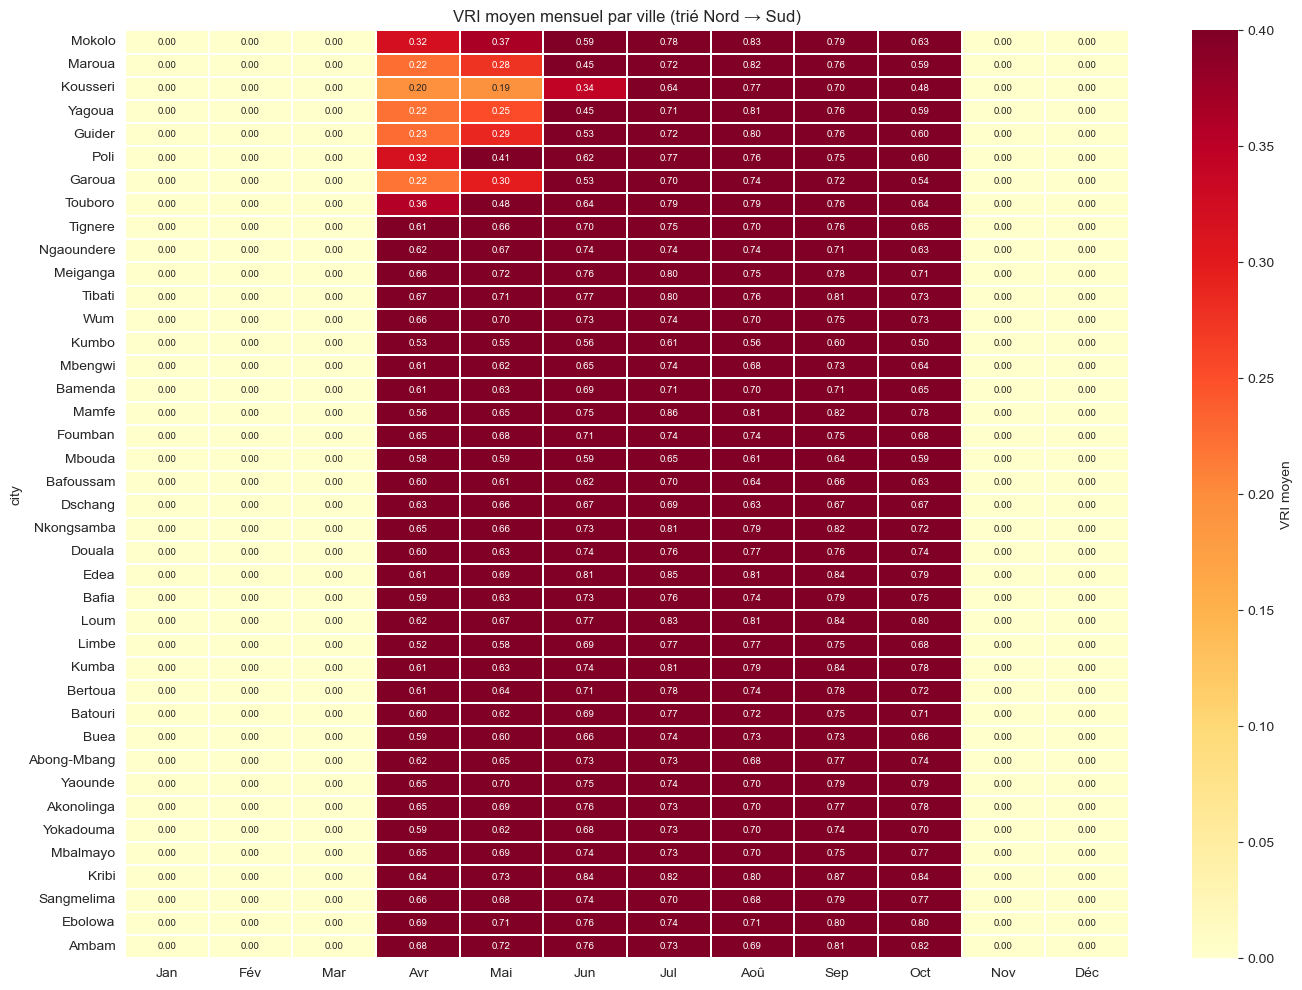

In [17]:
vri_monthly = (df_clean.groupby(['city', df_clean['time'].dt.month])['VRI']
               .mean().unstack(level=1))
vri_monthly.columns = ['Jan','Fév','Mar','Avr','Mai','Jun',
                        'Jul','Aoû','Sep','Oct','Nov','Déc']
city_lat = df_clean.groupby('city')['latitude'].mean().sort_values(ascending=False)
vri_monthly = vri_monthly.reindex(city_lat.index)
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(vri_monthly, cmap='YlOrRd', vmin=0, vmax=0.4,
            linewidths=0.3, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 7},
            ax=ax, cbar_kws={'label': 'VRI moyen'})
ax.set_title('VRI moyen mensuel par ville (trié Nord → Sud)', fontsize=12)
plt.tight_layout(); plt.show()


## 16. Relations VRI / variables météo
Scatter sous-échantillonné avec courbe de tendance. Les non-linéarités justifient les modèles à base d'arbres.

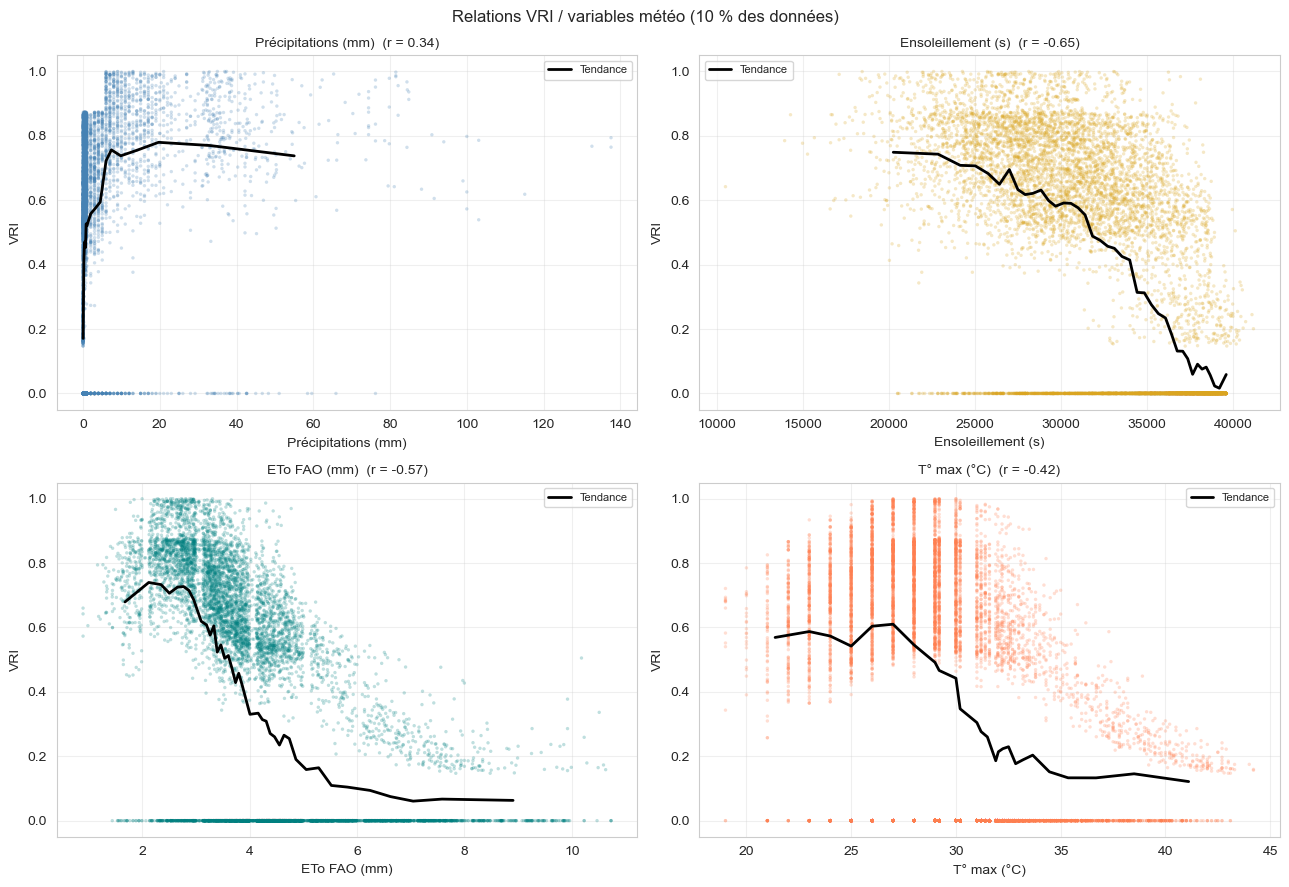

In [18]:
sample = df_clean.sample(frac=0.10, random_state=42)
key_vars = [
    ('precipitation_sum',          'Précipitations (mm)',    'steelblue'),
    ('sunshine_duration',          'Ensoleillement (s)',     'goldenrod'),
    ('et0_fao_evapotranspiration', 'ETo FAO (mm)',           'teal'),
    ('temperature_2m_max',         'T° max (°C)',            'coral'),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.flatten()
for ax, (col, xlabel, color) in zip(axes, key_vars):
    if col not in sample.columns: continue
    ax.scatter(sample[col], sample['VRI'], alpha=0.25, s=6, color=color, edgecolors='none')
    tmp = sample[[col,'VRI']].dropna().sort_values(col)
    q_bins = pd.qcut(tmp[col], q=40, duplicates='drop')
    trend  = tmp.groupby(q_bins, observed=True)['VRI'].mean()
    centers= tmp.groupby(q_bins, observed=True)[col].mean()
    ax.plot(centers, trend, color='black', linewidth=2, label='Tendance')
    r = sample[[col,'VRI']].corr().iloc[0,1]
    ax.set_title(f'{xlabel}  (r = {r:.2f})', fontsize=10)
    ax.set_xlabel(xlabel); ax.set_ylabel('VRI'); ax.legend(fontsize=8)
fig.suptitle('Relations VRI / variables météo (10 % des données)', fontsize=12)
plt.tight_layout(); plt.show()


## 17. Tendance interannuelle
Lissage 90 jours sur le VRI moyen toutes villes. Confirme l'absence de tendance pluriannuelle (Ft ≈ 0).

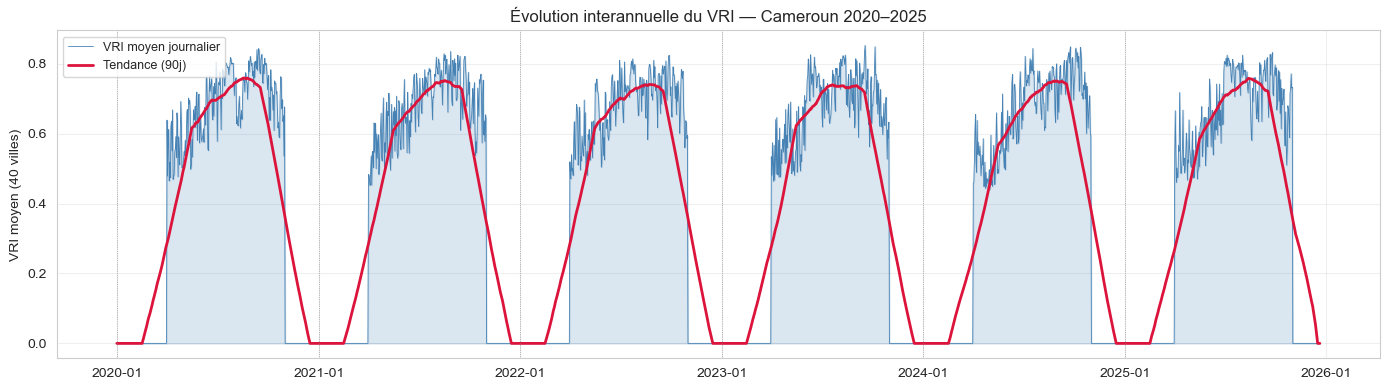

VRI moyen par année :
           mean    std  max
year_tmp                   
2020      0.402  0.365  1.0
2021      0.398  0.360  1.0
2022      0.399  0.358  1.0
2023      0.397  0.357  1.0
2024      0.391  0.357  1.0
2025      0.408  0.357  1.0


In [19]:
vri_daily = (df_clean.groupby('time')['VRI'].mean().reset_index()
             .rename(columns={'VRI':'VRI_mean'}))
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(vri_daily['time'], vri_daily['VRI_mean'], alpha=0.20, color='steelblue')
ax.plot(vri_daily['time'], vri_daily['VRI_mean'], linewidth=0.6,
        color='steelblue', label='VRI moyen journalier')
smooth = vri_daily['VRI_mean'].rolling(90, center=True, min_periods=30).mean()
ax.plot(vri_daily['time'], smooth, linewidth=2, color='crimson', label='Tendance (90j)')
for yr in range(2020, 2026):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='gray', linewidth=0.5, linestyle=':')
ax.set_ylabel('VRI moyen (40 villes)')
ax.set_title('Évolution interannuelle du VRI — Cameroun 2020–2025', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
df_clean['year_tmp'] = df_clean['time'].dt.year
print('VRI moyen par année :')
print(df_clean.groupby('year_tmp')['VRI'].agg(['mean','std','max']).round(3).to_string())
df_clean.drop(columns='year_tmp', inplace=True)


## 19. Test de causalité de Granger
Vérifie si les variables météo **causent au sens de Granger** le VRI. Un p-value < 0.05 justifie l'inclusion de la variable dans le modèle VAR.
Test effectué sur une ville représentative (Yaoundé) avec lag=7 jours.


## 18. Sauvegarde — `df_clean.pkl`

=== Test de Granger — Yaounde (lag max = 7) ===
                  Variable  Lag optimal  p-value Cause Granger VRI ?
et0_fao_evapotranspiration            1   0.0000               Oui ✓
       precipitation_hours            1   0.0000               Oui ✓
   shortwave_radiation_sum            7   0.0000               Oui ✓
         precipitation_sum            7   0.0009               Oui ✓
        wind_speed_10m_max            1   0.0030               Oui ✓
       temperature_2m_mean            1   0.0221               Oui ✓


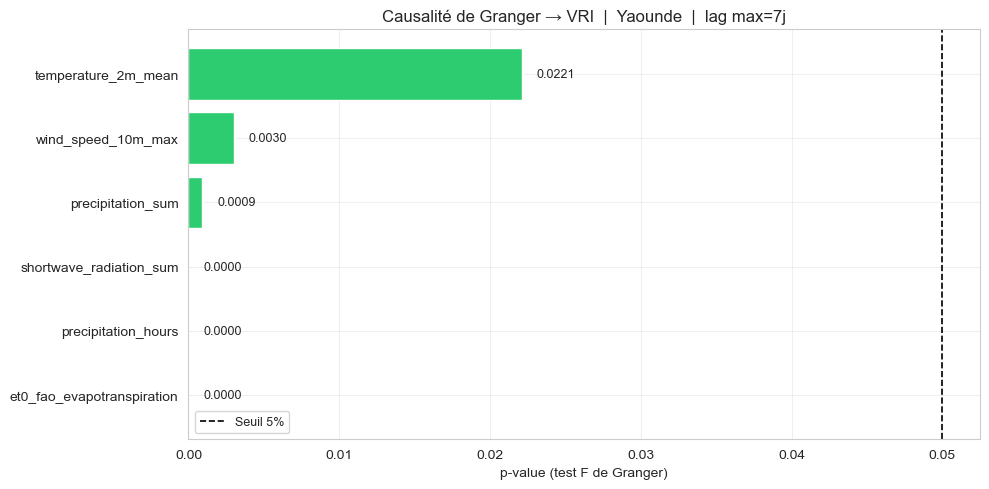


Variables retenues pour le VAR : ['et0_fao_evapotranspiration', 'precipitation_hours', 'shortwave_radiation_sum', 'precipitation_sum', 'wind_speed_10m_max', 'temperature_2m_mean']


In [20]:
from statsmodels.tsa.stattools import grangercausalitytests

ville_g = 'Yaounde' if 'Yaounde' in df_clean['city'].values else df_clean['city'].iloc[0]
df_g = (df_clean[df_clean['city'] == ville_g]
        .set_index('time')
        .sort_index()
        [['VRI','temperature_2m_mean','precipitation_sum',
          'precipitation_hours','et0_fao_evapotranspiration',
          'wind_speed_10m_max','shortwave_radiation_sum']]
        .dropna())

MAX_LAG = 7
granger_results = []

for col in df_g.columns.drop('VRI'):
    try:
        res = grangercausalitytests(df_g[['VRI', col]], maxlag=MAX_LAG, verbose=False)
        # p-value du test F au lag optimal (lag=7)
        pvals = [res[lag][0]['ssr_ftest'][1] for lag in range(1, MAX_LAG+1)]
        best_lag  = int(np.argmin(pvals) + 1)
        best_pval = pvals[best_lag - 1]
        granger_results.append({
            'Variable': col,
            'Lag optimal': best_lag,
            'p-value': round(best_pval, 4),
            'Cause Granger VRI ?': 'Oui ✓' if best_pval < 0.05 else 'Non ✗'
        })
    except Exception as e:
        granger_results.append({'Variable': col, 'Lag optimal': '-',
                                 'p-value': '-', 'Cause Granger VRI ?': f'Erreur: {e}'})

df_granger = pd.DataFrame(granger_results).sort_values('p-value')
print(f'=== Test de Granger — {ville_g} (lag max = {MAX_LAG}) ===')
print(df_granger.to_string(index=False))

# ── Visualisation ──
df_plot = df_granger[df_granger['p-value'] != '-'].copy()
df_plot['p-value'] = df_plot['p-value'].astype(float)
df_plot = df_plot.sort_values('p-value')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in df_plot['p-value']]
bars = ax.barh(df_plot['Variable'], df_plot['p-value'], color=colors, edgecolor='white')
ax.axvline(0.05, color='black', linestyle='--', linewidth=1.2, label='Seuil 5%')
ax.set_xlabel('p-value (test F de Granger)')
ax.set_title(f'Causalité de Granger → VRI  |  {ville_g}  |  lag max={MAX_LAG}j', fontsize=12)
ax.legend(fontsize=9)
for bar, (_, row) in zip(bars, df_plot.iterrows()):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{row['p-value']:.4f}", va='center', fontsize=9)
plt.tight_layout(); plt.show()

vars_significatives = df_granger[df_granger['Cause Granger VRI ?'] == 'Oui ✓']['Variable'].tolist()
print(f'\nVariables retenues pour le VAR : {vars_significatives}')


In [21]:
import pickle, os
os.makedirs('../outputs', exist_ok=True)
pickle.dump(df_clean,     open('../outputs/df_clean.pkl',    'wb'), protocol=4)
pickle.dump(NUMERIC_COLS, open('../outputs/numeric_cols.pkl','wb'), protocol=4)
print('Fichiers sauvegardés :')
print('  ../outputs/df_clean.pkl')
print('  ../outputs/numeric_cols.pkl')
print(f'Shape df_clean : {df_clean.shape}')


Fichiers sauvegardés :
  ../outputs/df_clean.pkl
  ../outputs/numeric_cols.pkl
Shape df_clean : (87240, 35)
